# KD Tree Band Assignment (Non-Hermitian)
This notebook loads a non-Hermitian dataset, assigns points to bands using a KD-Tree in the complex plane, and plots the results.

In [1]:
import json
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import heapq

sys.path.append('./original_code')
from original_code.plot import plot_nonhermitian_bands

In [2]:
# Load sample map to find non-Hermitian cases
with open('data/inputs.json', 'r') as f:
    sample_map = json.load(f)

non_hermitian_keys = [k for k, v in sample_map.items() if v.get('type') == 'non-hermitian']
print(f"Found {len(non_hermitian_keys)} non-Hermitian samples.")
print(f"First few keys: {non_hermitian_keys[:5]}")

Found 1296 non-Hermitian samples.
First few keys: ['3', '4', '5', '9', '10']


In [ ]:
# Indices to try
417, 677, 987, 1025, 1263, 1311, 1341, 1671

(417, 677, 987, 1025, 1263, 1311, 1341)

In [40]:
# Select a sample to process
#sample_key = non_hermitian_keys[0]
sample_key = 1671
data_path = f"data/arrays/{sample_key}.npz"
data = np.load(data_path)

q_vals = data['q_values']
omega_vals = data['omega_values']

print(f"Loaded {len(q_vals)} points for sample {sample_key}")

Loaded 4245 points for sample 1671


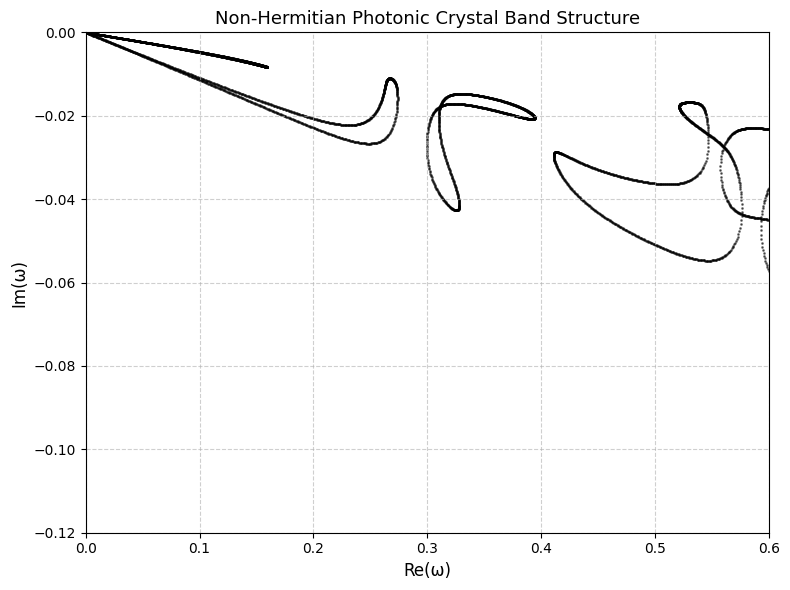

In [41]:
# Plot the unassigned dataset
plot_nonhermitian_bands(omega_vals, q_vals)

In [42]:
def assign_bands_kdtree(k_vals, omega_vals, k_neighbors=20, dist_thresh=0.05, alpha=0.1):
    """
    Assigns each point to a band using KD trees in the 3D space (Re(omega), Im(omega), k * alpha).
    Enforces that a band can only contain ONE point for any given k value to prevent bands from merging.
    """
    points_3d = np.column_stack((omega_vals.real, omega_vals.imag, k_vals * alpha))
    tree = KDTree(points_3d)
    
    num_points = len(omega_vals)
    assigned_bands = np.full(num_points, -1, dtype=int)
    
    band_id = 0
    unassigned_indices = set(range(num_points))
    
    while unassigned_indices:
        start_idx = unassigned_indices.pop()
        assigned_bands[start_idx] = band_id
        
        ks_in_band = {k_vals[start_idx]}
        pq = []
        
        dists, indices = tree.query(points_3d[start_idx], k=k_neighbors)
        for d, idx in zip(dists, indices):
            if d < dist_thresh and idx in unassigned_indices:
                heapq.heappush(pq, (d, idx))
                
        while pq:
            d, current_idx = heapq.heappop(pq)
            if current_idx not in unassigned_indices:
                continue
                
            current_k = k_vals[current_idx]
            if current_k in ks_in_band:
                continue  # Prevent coalescence/merging of multiple points with same k
                
            assigned_bands[current_idx] = band_id
            unassigned_indices.remove(current_idx)
            ks_in_band.add(current_k)
            
            dists, indices = tree.query(points_3d[current_idx], k=k_neighbors)
            for nd, idx in zip(dists, indices):
                if nd < dist_thresh and idx in unassigned_indices:
                    heapq.heappush(pq, (nd, idx))
                    
        band_id += 1
        
    return assigned_bands

assigned_bands = assign_bands_kdtree(q_vals, omega_vals)
unique_bands = np.unique(assigned_bands)
print(f"Assigned points to {len(unique_bands)} distinct bands.")

Assigned points to 7 distinct bands.


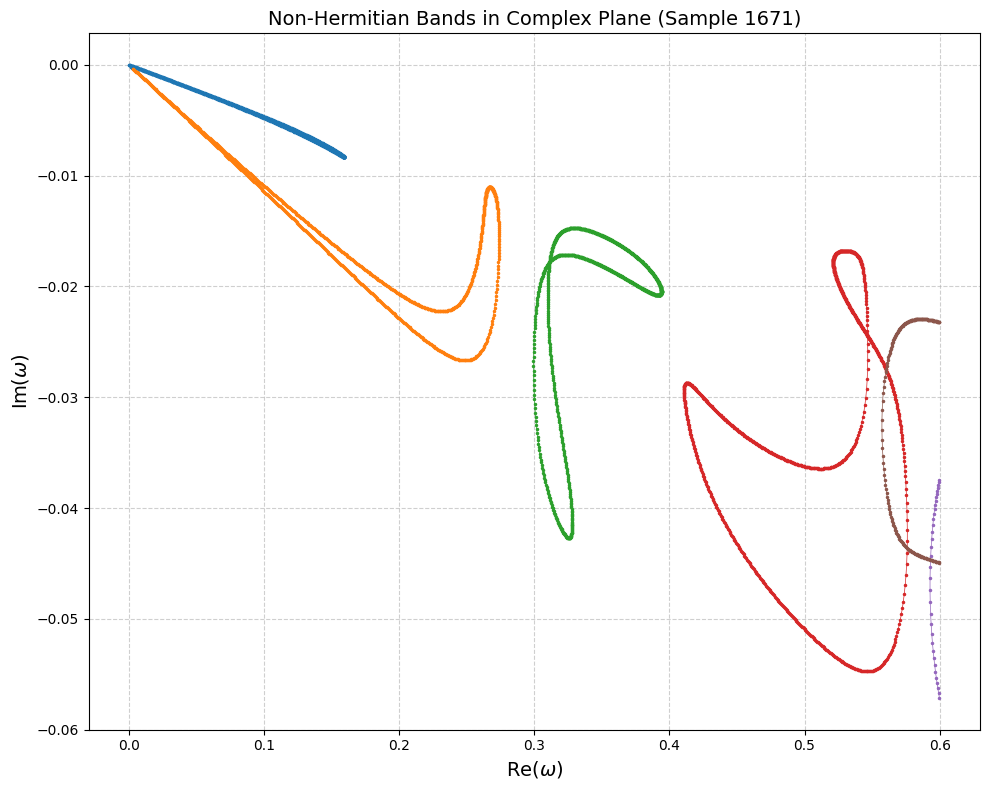

In [43]:
%matplotlib inline
plt.figure(figsize=(10, 8))

for b_id in unique_bands:
    mask = (assigned_bands == b_id)
    band_omegas = omega_vals[mask]
    
    if len(band_omegas) > 5:
        plt.plot(band_omegas.real, band_omegas.imag, marker='.', markersize=3, linestyle='-', linewidth=0.5, label=f'Band {b_id}')

plt.xlabel('Re($\\omega$)', fontsize=14)
plt.ylabel('Im($\\omega$)', fontsize=14)
plt.title(f'Non-Hermitian Bands in Complex Plane (Sample {sample_key})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

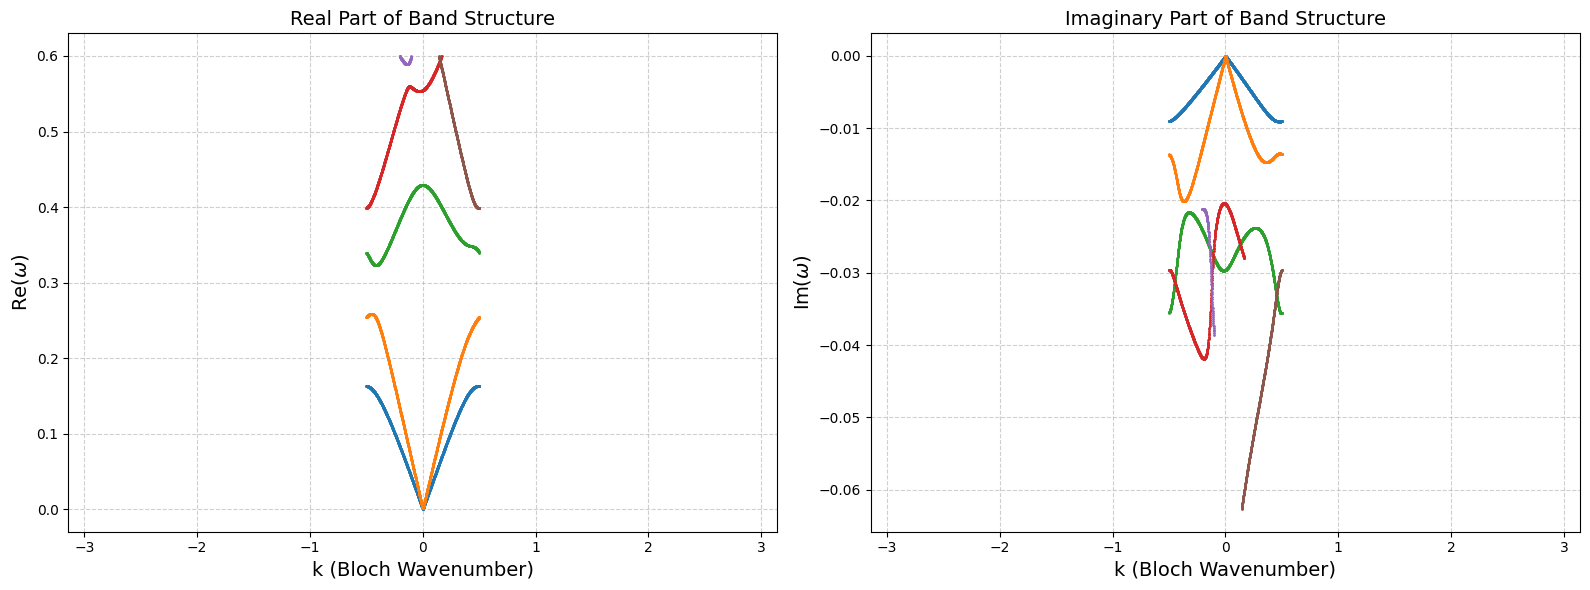

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for b_id in unique_bands:
    mask = (assigned_bands == b_id)
    band_ks = q_vals[mask]
    band_omegas = omega_vals[mask]
    
    if len(band_omegas) > 5:
        # Sort by k to ensure line plots correctly
        sort_idx = np.argsort(band_ks)
        band_ks = band_ks[sort_idx]
        band_omegas = band_omegas[sort_idx]
        
        ax[0].plot(band_ks, band_omegas.real, marker='.', markersize=2, linestyle='-', linewidth=0.5)
        ax[1].plot(band_ks, band_omegas.imag, marker='.', markersize=2, linestyle='-', linewidth=0.5)

ax[0].set_xlabel('k (Bloch Wavenumber)', fontsize=14)
ax[0].set_ylabel('Re($\\omega$)', fontsize=14)
ax[0].set_title('Real Part of Band Structure', fontsize=14)
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_xlim(-np.pi, np.pi)

ax[1].set_xlabel('k (Bloch Wavenumber)', fontsize=14)
ax[1].set_ylabel('Im($\\omega$)', fontsize=14)
ax[1].set_title('Imaginary Part of Band Structure', fontsize=14)
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_xlim(-np.pi, np.pi)

plt.tight_layout()
plt.show()